In [122]:
import numpy as np
import openflash
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter
print(type(openflash))
print(openflash.__path__)
print(openflash.__file__)

# --- Import core modules from package ---
try:
    from openflash import *
    from openflash.multi_equations import *
    from openflash.multi_constants import g
    print("OpenFLASH modules imported successfully!")
except ImportError as e:
    print(f"Error importing OpenFLASH modules. Error: {e}")

# Set NumPy print options for better readability
np.set_printoptions(threshold=np.inf, linewidth=np.inf, precision=8, suppress=True)
from openflash.multi_constants import rho
from openflash.multi_equations import wavenumber

# Now you can import from the folder structure
# Assuming 'pyplotutilities' is a folder inside 'sea-lab-utils'
import sys
from pathlib import Path
HERE = Path.cwd().resolve()
fig_path_1_str = str((HERE / ".." / "pubs" / "JFM" / "figs" / "alpha-beta-explanation.pdf").resolve())
store_path2_str = str((HERE / "data" / "fit-function-choice.pkl").resolve())

dir_path_1_str = str((HERE / ".." / "dev" / "python" / "convergence-study"))
dir_path_2_str = str((HERE / ".." / "dev" / "python"))
dir_path_3_str = str((HERE / ".." / "sea-lab-utils").resolve())

data_1_str = str((HERE / ".." / "dev" / "python" / "convergence-study" / "i-region-convergence" / "middle-region" / "data" / "predetermined-4.pkl"))

for dir_path in [dir_path_1_str, dir_path_2_str, dir_path_3_str]:
  if dir_path not in sys.path:
    sys.path.insert(0, dir_path)

from helpers import *
from pyplotutilities import colors
from pyplotutilities import fonts
colors.get_colors()
print(colors.purple)
fonts.get_fonts()

<class 'module'>
['/Users/Bimali/Desktop/SEALab/OpenFLASH/package/src/openflash']
/Users/Bimali/Desktop/SEALab/OpenFLASH/package/src/openflash/__init__.py
OpenFLASH modules imported successfully!
#CC79A7


In [23]:
# Non-slanted CorPower WEC geometry
h = 50.00
omega_val = 1
m0 = wavenumber(omega_val, h)
d = [14.45, 7.13, 2.05]
a = [1.25, 2.725, 4.2]
nmk_max = 200
nmk_big = 150
NMK = [nmk_max for _ in range(4)] # number of coefficients in each region
heaving = [0, 1, 0]

prob1 = ConvergenceProblemI(h, d, a, heaving, NMK, m0, rho)
mk1 = prob1.m_k
info1 = {"h" : h,
        "d" : d,
        "a" : a,
        "region" : 1,
        "m0s" : [m0]}
data1 = merge_dicts(info1, prob1.convergence_study_over_m0s(nmk_big, [m0], [mk1]))

In [47]:
# Plot Settings
l_width = 3 # line width
m_size = 7 # marker size
lab_fs = 11 # x and y label font size
leg_fs = lab_fs  # legend font size
fig_h = 9 # figure height
fig_w = 4 # figure width

In [111]:
def plot_type_1(ax, cf, m0, hydro, alpha, beta, loc):
  if hydro == "am": subscript, ylab = "A", "Added Mass"
  elif hydro == "dp": subscript, ylab = "B", "Damping"
  xs = list(range(1, len(cf[m0][hydro + "s"]) + 1))
  xmin, xmax = 0, len(xs) + 1
  ys = cf[m0][hydro + "s"]
  true_val = cf[m0][hydro]
  ymin, ymax = 0, max(ys + [true_val])*1.1
  ax.scatter(xs, ys, c = colors.blue, s= 5, zorder = 8, label = "Empirical/Computed")
  ax.hlines(true_val, xmin, xmax, color = colors.green, label = rf"True Value ($N_{{i_2}} = 200$)", zorder = 4)
  err_xs_1 = xs + [xmax]
  err_xs_2 = [0] + err_xs_1
  err_fracs = [(x/beta)**(-alpha) for x in ([0.1] + err_xs_1)]
  ax.set_xlim([xmin, xmax])
  ax.set_ylim([ymin, ymax])
  err_lows = [(1 - err_frac) * true_val for err_frac in err_fracs]
  err_highs = [(1 + err_frac) * true_val for err_frac in err_fracs]
  ax.plot(err_xs_2, err_lows, color = colors.orange, linewidth = 1, zorder = 3)
  ax.plot(err_xs_2, err_highs, color = colors.orange, linewidth = 1, zorder = 2)
  ax.fill_between(err_xs_2, err_lows, err_highs,
                  alpha=0.3, color = colors.orange,
                  label=rf"$\epsilon_{subscript} \leq (\frac{{N^{{i2}}}}{{\beta_{subscript}}})^{{-\alpha_{subscript}}}$", zorder = 1)
  ax.set_ylabel(ylab, fontsize = lab_fs)
  ax.legend(loc=loc, fontsize=leg_fs * 1.1, frameon=False)

def plot_type_2(ax, cf, m0, hydro):
  if hydro == "am": subscript = "A"
  elif hydro == "dp": subscript = "B"
  xs = list(range(1, len(cf[m0][hydro + "s"]) + 1))
  xmin, xmax = 0, len(xs) + 1
  xs2 = [0.05] + xs + [xmax]
  true_val = cf[m0][hydro]
  ys = [np.log(np.abs((entry - true_val)/true_val)) for entry in cf[m0][hydro + "s"]]
  ax.scatter(xs, ys, c = colors.blue, label = "Empirical/Computed", s = 8, zorder = 3)
  ymin, ymax = min(ys) - 0.5, max(ys) + 0.5
  popt, pcov = curve_fit(lambda x, a1, a2 : (- a1 * np.log(x/a2)), xs, ys, p0=(1, 1))
  alpha, beta = popt
  ys2 = [- alpha * np.log(x/beta) for x in xs2]
  ax.plot(xs2, ys2, color = colors.orange, label = rf"Fit with $-\alpha_{subscript}\mathrm{{ln}}(\frac{{N^{{i2}}}}{{\beta_{subscript}}})$", zorder = 5)
  ax.hlines(np.log(0.01), xmin, xmax, label = rf"$1\%$ error", linestyle = "--", color = colors.green)
  ax.legend(loc='upper right', fontsize=leg_fs*1.1, frameon=False)
  ax.set_xlim([xmin, xmax])
  ax.set_ylim([ymin, ymax])
  ax.set_ylabel(rf"$\mathrm{{ln}}|\epsilon_{subscript}|$", fontsize = lab_fs)
  return alpha, beta

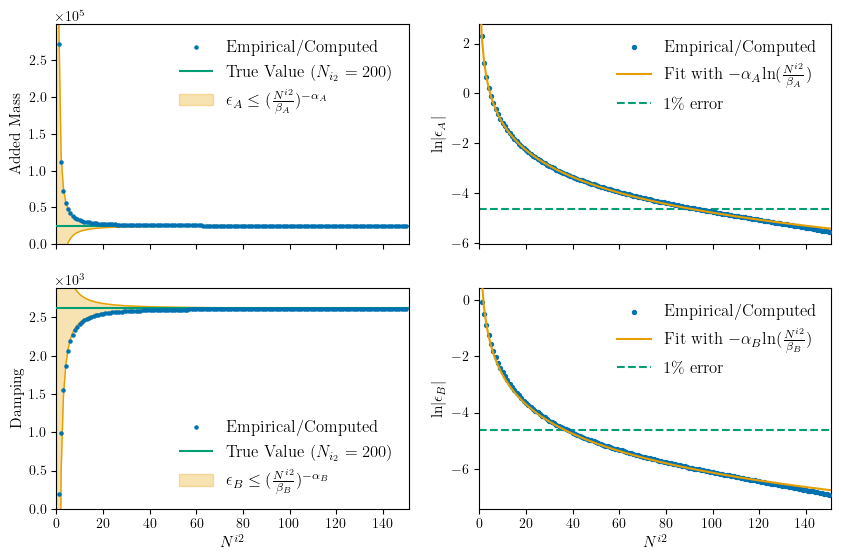

In [112]:
fig, axs = plt.subplots(2, 2, figsize=(fig_w * 2.5, fig_h * 0.7), sharex='col')
for a in axs.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1)) 
    a.yaxis.set_major_formatter(formatter)
alpha, beta = plot_type_2(axs[0][1], data1, m0, "am")
plot_type_1(axs[0][0], data1, m0, "am", alpha, beta, loc = "upper right")
alpha, beta = plot_type_2(axs[1][1], data1, m0, "dp")
plot_type_1(axs[1][0], data1, m0, "dp", alpha, beta, loc = "lower right")
for ax in [axs[1][0], axs[1][1]]:
    ax.set_xlabel(rf"$N^{{i2}}$", fontsize = lab_fs)
fig.savefig(fig_path_1_str, format='pdf', dpi=300, bbox_inches='tight')

In [123]:
data2 = open_pkl_file(data_1_str)[1]
_ = generate_log_data(data2)

In [ ]:
def plot_type_3(ax, cfs, hydro):
  if hydro == "am": subscript = "A"
  elif hydro == "dp": subscript = "B"
  xs = list(range(1, len(cfs[0][cfs[0]["m0s"][0]][hydro + "s"]) + 1))
  xmin, xmax = 0, len(xs) + 1
  xs2 = [0.05] + xs + [xmax]
  hmdr_f = lambda cf : (cf["h"]-cf["d"][1])/(cf["a"][1]-cf["a"][0])
  map_colors = color_by_f_value(hmdr_f, cfs, cmap = "viridis")
  all_ys, alphas, betas = [], [], []
  for i in range(len(cfs)):
    cf = cfs[i]
    m0 = cf["m0s"][0]
    true_val = cf[m0][hydro]
    ys = [np.log(np.abs((entry - true_val)/true_val)) for entry in cf[m0][hydro + "s"]]
    popt, pcov = curve_fit(lambda x, a1, a2 : (- a1 * np.log(x/a2)), xs, ys, p0=(1, 1))
    alphas.append(popt[0])
    betas.append(popt[1])
    ys2 = [- alpha * np.log(x/beta) for x in xs2]

    ax.scatter(xs, ys, c = map_colors[i], s = 8, zorder = 3)
    ax.plot(xs2, ys2, color = map_colors[i], label = rf"Fit with $-\alpha_{subscript}\mathrm{{ln}}(\frac{{N^{{i2}}}}{{\beta_{subscript}}})$", zorder = 5)

  every_y_lst = [entry for ys in all_ys for entry in ys]
  ymin, ymax = min(ys) - 0.5, max(ys) + 0.5
  popt, pcov = curve_fit(lambda x, a1, a2 : (- a1 * np.log(x/a2)), xs, ys, p0=(1, 1))
  alpha, beta = popt
  ys2 = [- alpha * np.log(x/beta) for x in xs2]
  ax.plot(xs2, ys2, color = colors.orange, label = rf"Fit with $-\alpha_{subscript}\mathrm{{ln}}(\frac{{N^{{i2}}}}{{\beta_{subscript}}})$", zorder = 5)
  ax.hlines(np.log(0.01), xmin, xmax, label = rf"$1\%$ error", linestyle = "--", color = colors.green)
  ax.legend(loc='upper right', fontsize=leg_fs*1.1, frameon=False)
  ax.set_xlim([xmin, xmax])
  ax.set_ylim([ymin, ymax])
  ax.set_ylabel(rf"$\mathrm{{ln}}|\epsilon_{subscript}|$", fontsize = lab_fs)